# Reward Distribution Analysis
Load a model run directory containing a `step_info.jsonl` and summarize reward distributions across steps.

In [38]:
from pathlib import Path
import json
from typing import List, Dict, Any, Sequence, Optional
import pandas as pd
import matplotlib.pyplot as plt

def load_step_info(run_dir: str | Path, step_file: str = 'step_info.jsonl') -> pd.DataFrame:
    p = Path(run_dir) / step_file
    if not p.exists():
        raise FileNotFoundError(f'File not found: {p}')
    records: List[Dict[str, Any]] = []
    with p.open('r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            base = {
                'timestep': int(rec.get('timestep', -1)),
                'env_index': int(rec.get('env_index', -1)),
            }
            info = rec.get('info', {}) or {}
            flat: Dict[str, Any] = {}
            for k, v in info.items():
                if isinstance(v, (int, float, str, bool)) or v is None:
                    flat[k] = v
            for key in ('reward', 'rewards'):
                if isinstance(info.get(key), dict):
                    for rk, rv in info[key].items():
                        if isinstance(rv, (int, float)):
                            flat[f'reward_{rk}'] = rv
            records.append({**base, **flat})
    df = pd.DataFrame.from_records(records)
    if 'timestep' in df.columns:
        df = df.sort_values('timestep').reset_index(drop=True)
    return df

def plot_reward_histograms(
    df: pd.DataFrame,
    step_size: int,
    update_index: int,
    x_min: float = -100,
    x_max: float = 100,
    reward_cols: Optional[Sequence[str]] = None,
):
    if df is None or df.empty:
        raise ValueError('Empty DataFrame provided')
    if update_index < 1:
        raise ValueError('update_index must be >= 1')
    max_timestep_exclusive = update_index * step_size
    sel = df[df.get('timestep', 0) < max_timestep_exclusive].copy()
    if sel.empty:
        raise ValueError(f'No data for update_index={update_index} with step_size={step_size}')
    if reward_cols is None:
        candidates = ['reward_total','reward_carbon','reward_wait_schedule','reward_wait']
        reward_cols = [c for c in candidates if c in sel.columns]
    if not reward_cols:
        raise ValueError('No reward columns found to plot')
    fig, axes = plt.subplots(1, len(reward_cols), figsize=(5*len(reward_cols), 4))
    if len(reward_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, reward_cols):
        data = pd.to_numeric(sel[col], errors='coerce').dropna()
        ax.hist(data, bins=1000, color='steelblue', edgecolor='black', alpha=0.8, )
        ax.set_xlim(x_min, x_max)
        ax.set_title(f'{col} (steps < {max_timestep_exclusive})')
        ax.set_xlabel(col)
        ax.set_ylabel('count')
        ax.grid(alpha=0.2)
    fig.suptitle(f'Reward distributions up to update {update_index}')
    fig.tight_layout()
    return fig


/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_36416/156436982.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


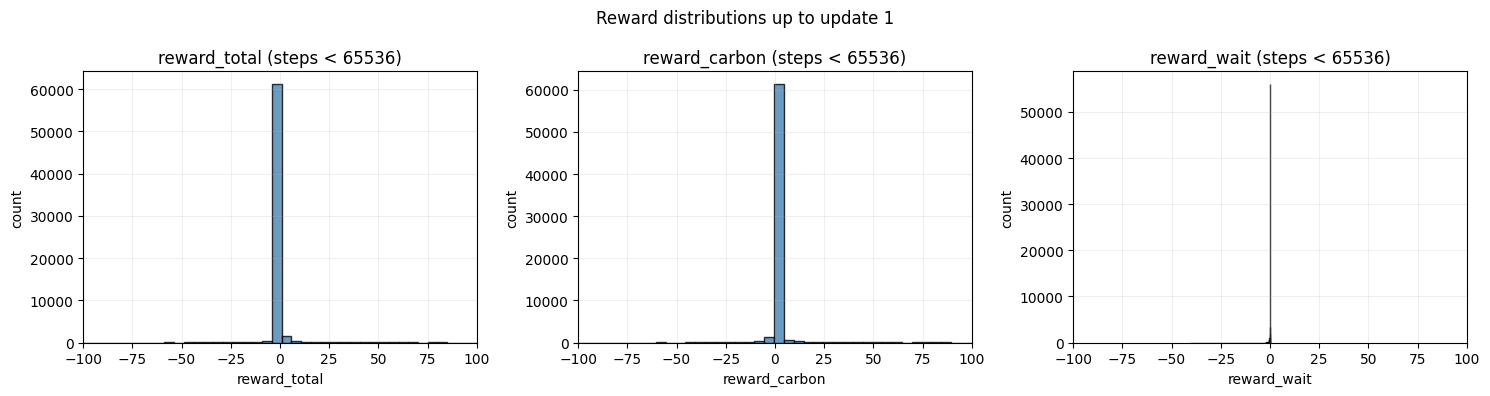

In [33]:
# Example usage:
df = load_step_info('results/reward_analysis/no_wait_scaling', 'step_info.jsonl')
fig = plot_reward_histograms(df, step_size=65536, update_index=1, x_min=-100, x_max=100)
fig.show()


/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_36416/3205129486.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


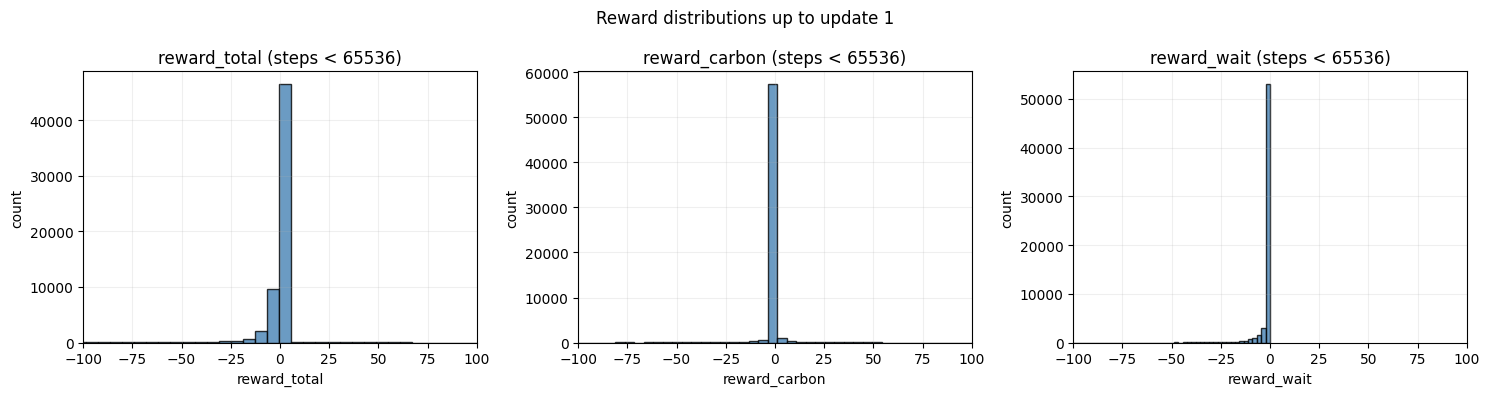

In [35]:
# Example usage:
df = load_step_info('results/reward_analysis/100*wait,old_Data', 'step_info.jsonl')
fig = plot_reward_histograms(df, step_size=65536, update_index=1, x_min=-100, x_max=100)
fig.show()


/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_36416/2620058591.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


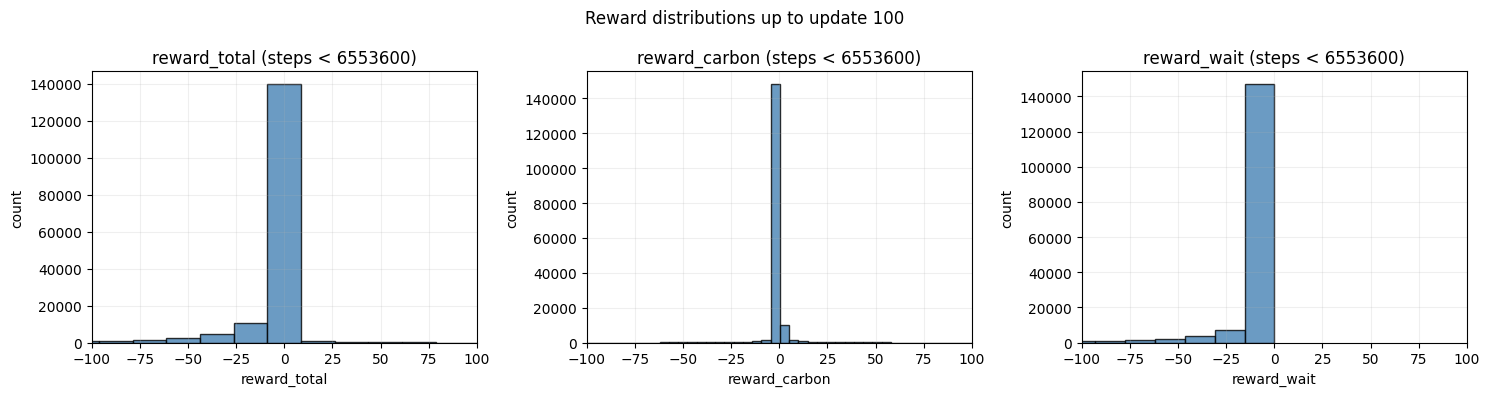

In [ ]:
# Example usage:
df = load_step_info('results/reward_analysis/new_data')
fig = plot_reward_histograms(df, step_size=65536, update_index=100, x_min=-100, x_max=100)
fig.show()

/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_36416/2518214682.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


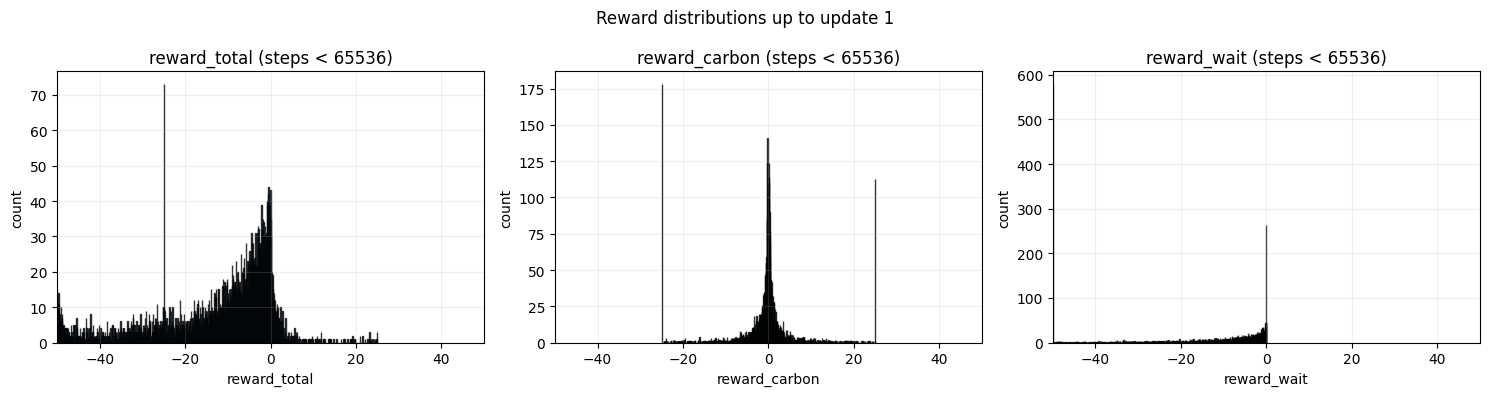

In [ ]:
# Example usage:
df = load_step_info('results/reward_analysis/abs_clip', 'step_info.jsonl')
df = df[df['reward_total'] != 0]
fig = plot_reward_histograms(df, step_size=65536, update_index=1, x_min=-50, x_max=50)
fig.show()

/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_36416/2518214682.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


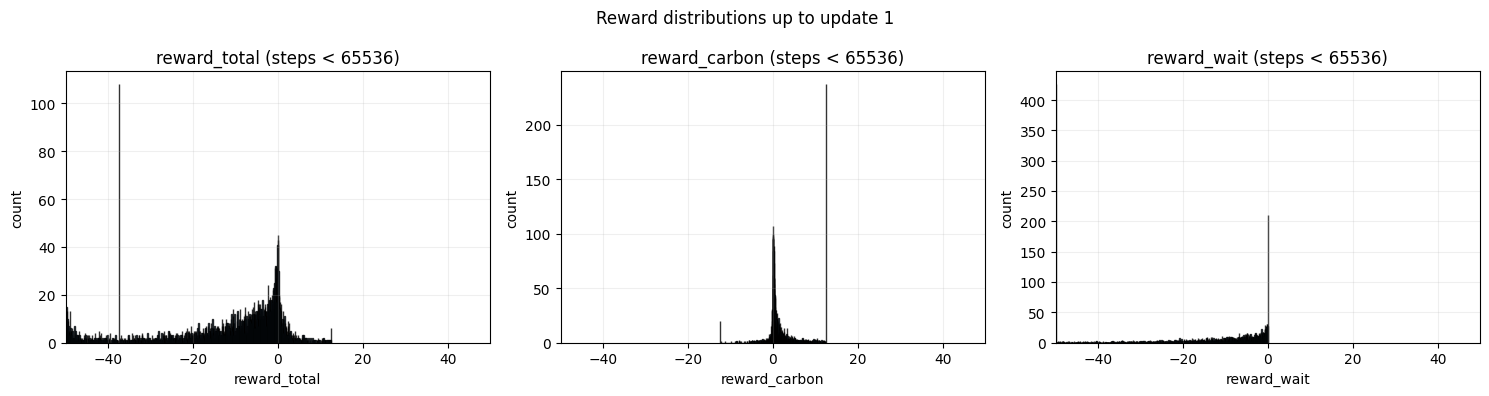

In [50]:
# Example usage:
df = load_step_info('results/CI_B4096_RC_LR-00000_ETA0.5_C-None_Lu', 'step_info.jsonl')
df = df[df['reward_total'] != 0]
fig = plot_reward_histograms(df, step_size=65536, update_index=1, x_min=-50, x_max=50)
fig.show()

/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_36416/2518214682.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


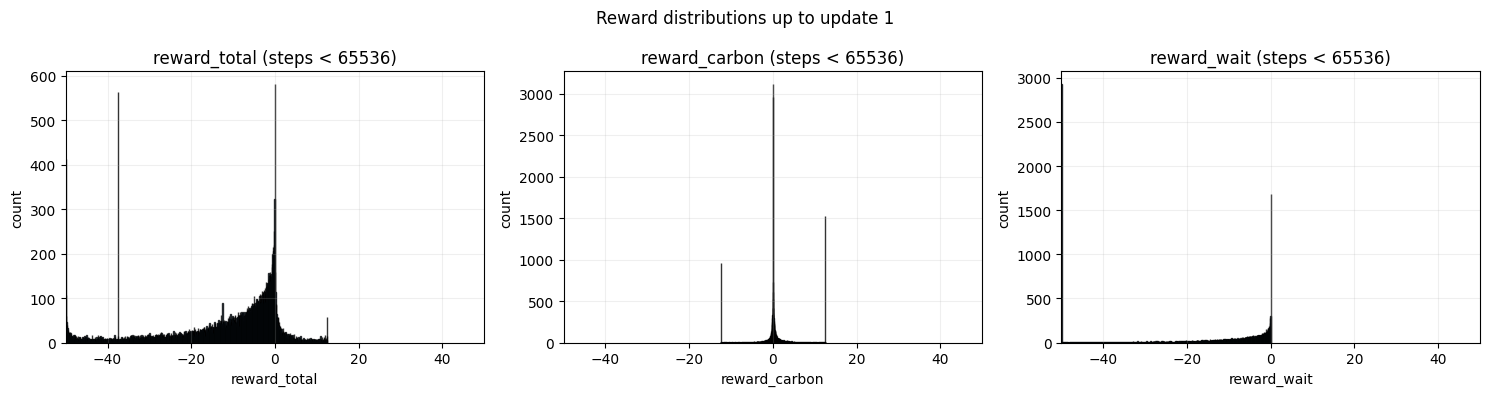

In [51]:
# Example usage:
df = load_step_info('results/CI_B4096_RC_LR-00000_ETA0.5_C-None_Lu', 'step_info.jsonl')
df = df[df['reward_total'] != 0]
fig = plot_reward_histograms(df, step_size=65536, update_index=1, x_min=-50, x_max=50)
fig.show()